In [1]:
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
np.random.seed(1001)

In [2]:
# I would like to give here yet another example for the usage of eigenvalue optimization.

# Assume we have an ant living in the plane that wants to find out more about the environment it is
# living in. We as observers can see where the ant is located at, that is in cartesian coordinates:
ants_position = np.array([3, 4])

# In this plane there is now also a solid object, a circle, which we as observers can describe as
circle_radius = 2
circle_origin = np.array([0, 0])

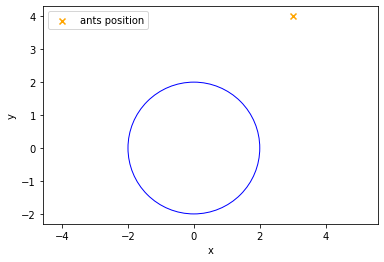

In [3]:
# Lets have an overview of the situation
plt.axis('equal')
ax = plt.gca()
ax.add_patch(plt.Circle(circle_origin, circle_radius, color='b', fill=False))
ax.scatter(ants_position[0], ants_position[1], marker='x', color='orange', label='ants position')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

In [4]:
# The ant has now also LIDAR sensor (of course, hehe) with which he can probe its environment. The sensor
# gives back as information an angle together with a distance measurment from whatever direction the ant
# is pointing the LIDAR at.

# For this, lets now create a helper function that, given a directional unit vector v outputs the distance 
# (in case there is an intersect) to the circle (defined by the above parameters), 
# seen from the ants position defined above. In case there is no intersect the return value is infinity
def intersect(v):
    a = np.sum(v**2, axis=-1)
    b = 2 * np.sum(v * (ants_position - circle_origin), axis=-1)
    c = np.sum((ants_position - circle_origin)**2, axis=-1) - circle_radius**2
    
    d = b**2 - 4 * a * c
    
    with np.errstate(all='ignore'):
        d = np.where(d > 0, np.sqrt(d), np.inf)
        
        t1 = (-b + d) / (2 * a)
        t2 = (-b - d) / (2 * a)
        
        t1 = np.where(t1 >= 0, t1, np.inf)
        t2 = np.where(t2 >= 0, t2, np.inf)
        
        t = np.where(t1 < t2, t1, t2)
        
    return t

# The ant now takes some measurement around his position. He points the LIDAR sensor along the angles:
angles = np.arange(360) * np.pi / 180
# which correspond to the following directional vectors
vectors = np.concatenate([np.cos(angles).reshape(-1, 1), np.sin(angles).reshape(-1, 1)], axis=1)

# The measurements along theese angles now give back the following distance values
distances = intersect(vectors)

# From which we only keep the finite ones (no intersections give back an infinite distance)
arg = np.isfinite(distances)
angles = angles[arg]
distances = distances[arg]
vectors = vectors[arg, :]

# From this values we can now create some positional information about the object which the ant sees, 
# in Cartesian coordinates, with the center at the observer we get
xy = vectors * distances.reshape(-1, 1)

# We can also add some noise to it
noise_level = 1e-2

xy = xy + np.random.randn(xy.shape[0], xy.shape[1]) * noise_level

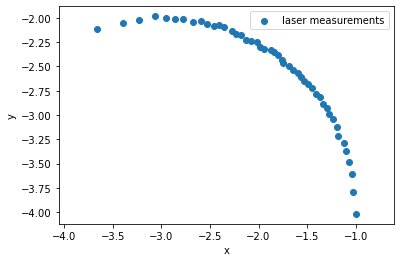

In [5]:
# Lets check out those measurements
plt.axis('equal')
ax = plt.gca()
ax.scatter(xy[:, 0], xy[:, 1], label='laser measurements')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

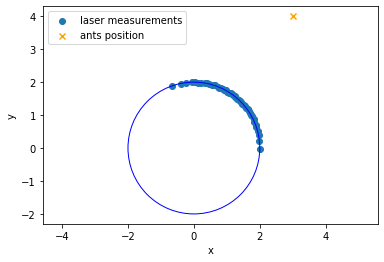

In [6]:
# Seen from our global observer position, together with the actaul circle and the ants position
plt.axis('equal')
ax = plt.gca()
ax.scatter(xy[:, 0] + ants_position[0], xy[:, 1] + ants_position[1], label='laser measurements')
ax.add_patch(plt.Circle(circle_origin, circle_radius, color='b', fill=False))
ax.scatter(ants_position[0], ants_position[1], marker='x', color='orange', label='ants position')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

In [7]:
# Now lets say the ant knows that the object it sees is a circle, however not of which raidus nor its distance
# to the center. It would like to find out more about his position in relation to the cirecles center. 
# Pretty likely there exists a simple way for getting the circles properties from the LIDAR measurments, 
# however our ant likes challenges. Thats why it decides to look at his data in polar coordinates.

# The function converting the values is
def to_polar(xy, der=False):
    r = np.linalg.norm(xy, axis=1)
    a = np.arctan2(xy[:, 1], xy[:, 0])
    
    ar = np.concatenate([a.reshape(-1, 1), r.reshape(-1, 1)], axis=1)
    
    if der:
        d_a_d_x = -xy[:, 1] / np.sum(xy**2, axis=1)
        d_a_d_y = xy[:, 0] / np.sum(xy**2, axis=1)
        
        d_r_d_x = xy[:, 0] / r
        d_r_d_y = xy[:, 1] / r
        
        J_ar = np.zeros((2,) + ar.shape)
        J_ar[0, :, 0] = d_a_d_x
        J_ar[1, :, 0] = d_a_d_y
        J_ar[0, :, 1] = d_r_d_x
        J_ar[1, :, 1] = d_r_d_y
        
        return ar, J_ar
    else:
        return ar
    
# The ants data in polar coordinates is then
ar = to_polar(xy)

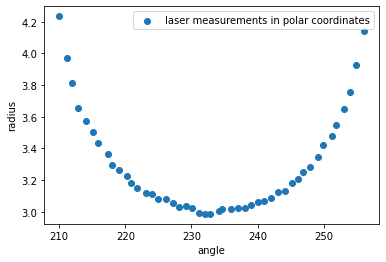

In [8]:
# Lets have a look at it
ax = plt.gca()
ax.scatter(np.mod(ar[:, 0], 2 * np.pi) * 180 / np.pi, ar[:, 1], label='laser measurements in polar coordinates')
ax.set_xlabel('angle')
ax.set_ylabel('radius')
ax.legend()
plt.show()

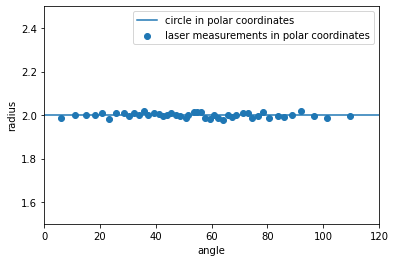

In [9]:
# Since our ant is a smart one, it knows that if it would be standing at the center of the circle, its data
# in polar coordinates would look like a flat line. Indeed, we as observers can confirm that
ar = to_polar(xy + ants_position)

ax = plt.gca()
plt.ylim(1.5, 2.5)
plt.xlim(0, 120)
ax.scatter(np.mod(ar[:, 0], 2 * np.pi) * 180 / np.pi, ar[:, 1], label='laser measurements in polar coordinates')
ax.plot((0, 360), (circle_radius, circle_radius), label='circle in polar coordinates')
ax.set_xlabel('angle')
ax.set_ylabel('radius')
ax.legend()
plt.show()

In [10]:
# The ant therefore wants to try and find a value v such that, the points transformed by v, and
# looked at in polar coordinates form a line as fine as possible. It can try to find this value 
# through least squares optimization.

# The ant creates his loss function, taking as input v a guess for its position in relation
# to the circles center, given in cartesian coordinates
def loss(v):
    ar = to_polar(xy + v).reshape(-1, 2, 1)
    
    mu = np.mean(ar, axis=0)
    S = np.mean(ar @ np.swapaxes(ar, -1, -2), axis=0) - mu @ np.swapaxes(mu, -1, -2)

    w, _ = np.linalg.eigh(S)
    w = w[0].reshape(-1)
    
    return w

def d_loss(v):
    ar, d_ar = to_polar(xy + v, der=True)
    d_ar = d_ar.reshape(2, -1, 2, 1)
    ar = ar.reshape(-1, 2, 1)
    
    mu = np.mean(ar, axis=0)
    d_mu = np.mean(d_ar, axis=1)
    
    S = np.mean(ar @ np.swapaxes(ar, -1, -2), axis=0) - mu @ np.swapaxes(mu, -1, -2)
    d_S = np.mean(d_ar @ np.swapaxes(ar, -1, -2), axis=1) + \
          np.mean(ar @ np.swapaxes(d_ar, -1, -2), axis=1) - \
          d_mu @ np.swapaxes(mu, -1, -2) - \
          mu @ np.swapaxes(d_mu, -1, -2)
          
    w, v = np.linalg.eigh(S)
    w, v = w[0], v[:, [0]]
    d_w = (np.swapaxes(v, -1, -2) @ d_S @ v).reshape(1, -1)
    
    return d_w

In [11]:
# And the ant tries to optimize it, with starting value a wild guess
v0 = np.array([0, 0])
res = least_squares(loss, v0, d_loss, method='trf', 
                    gtol=None, xtol=None, max_nfev=None)

In [12]:
# Something must have gone wrong. The guess for the spectators position is way off
print(res.x)

[-14.18742199   1.98324112]


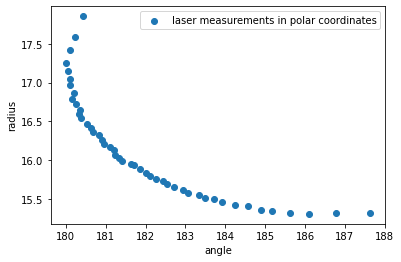

In [13]:
# The middle values appear flatter, but thats not the way we expected it to work
ar = to_polar(xy + res.x)

ax = plt.gca()
ax.scatter(np.mod(ar[:, 0], 2 * np.pi) * 180 / np.pi, ar[:, 1], label='laser measurements in polar coordinates')
ax.set_xlabel('angle')
ax.set_ylabel('radius')
ax.legend()
plt.show()

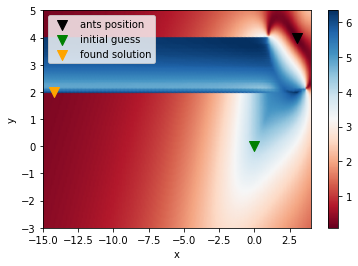

In [14]:
# Indeed, if we plot the loss functions across different starting values v, we see that there is quite some slope
# inbetween the minima and our initial guess. (Black is the actual optima, green our initial guess 
# and orange the found solution)
steps = 200
x_range = (-15, 4)
y_range = (-3, 5)

x_values, y_values, f_values = [], [], []

for x_value in np.linspace(x_range[0], x_range[1], steps):
    for y_value in np.linspace(y_range[0], y_range[1], steps):
        v = np.array([x_value, y_value])

        x_values.append(x_value)
        y_values.append(y_value)
        f_values.append(loss(v))

x_values = np.array(x_values).reshape(steps, steps)
y_values = np.array(y_values).reshape(steps, steps)
f_values = np.array(f_values).reshape(steps, steps)

# some rescaling in order to see the valley better
f_values = np.log(f_values * 1e3 + 1)

ax = plt.gca()

plot = plt.pcolormesh(x_values, y_values, f_values, cmap='RdBu', shading='gouraud')
ax.scatter(ants_position[0], ants_position[1], marker='v', s=100, color='k', label='ants position')
ax.scatter(v0[0], v0[1], marker='v', s=100, color='g', label='initial guess')
ax.scatter(res.x[0], res.x[1], marker='v', s=100, color='orange', label='found solution')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.colorbar(plot)

plt.show()

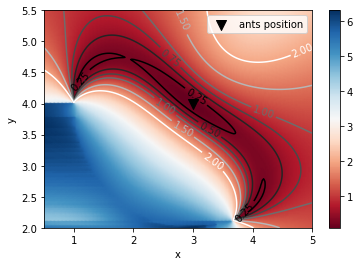

In [15]:
# This is likely due to the incontinuity regarding the smallest eigenvalues. If we look at the map close to
# the actual optima, we see however that in this region the problem is well defined.
steps = 200
x_range = (0.5, 5)
y_range = (2, 5.5)

x_values, y_values, f_values = [], [], []

for x_value in np.linspace(x_range[0], x_range[1], steps):
    for y_value in np.linspace(y_range[0], y_range[1], steps):
        v = np.array([x_value, y_value])

        x_values.append(x_value)
        y_values.append(y_value)
        f_values.append(loss(v))

x_values = np.array(x_values).reshape(steps, steps)
y_values = np.array(y_values).reshape(steps, steps)
f_values = np.array(f_values).reshape(steps, steps)

# some rescaling in order to see the valley better
f_values = np.log(f_values * 1e3 + 1)

ax = plt.gca()

plot = plt.pcolormesh(x_values, y_values, f_values, cmap='RdBu', shading='gouraud')
cset = plt.contour(x_values, y_values, f_values, cmap='gray',
                  levels=np.array([0.25, 0.5, 0.75, 1, 1.5, 2])) 
ax.clabel(cset, inline=True)
ax.scatter(ants_position[0], ants_position[1], marker='v', s=100, color='k', label='ants position')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.colorbar(plot)

plt.show()

In [16]:
# Lets give the ant a small hint to start the optimization closer at the actual solution
v0 = np.array([2.5, 4.5])
res = least_squares(loss, v0, d_loss, method='trf',
                    gtol=None, xtol=None, max_nfev=None)

In [17]:
# This looks better. Without knowing any properties about the circle beforehand (and our small help),
# the ant managed to estimate its position from the cirecles center fairly well
print(res.x)

[2.94418955 4.03211298]


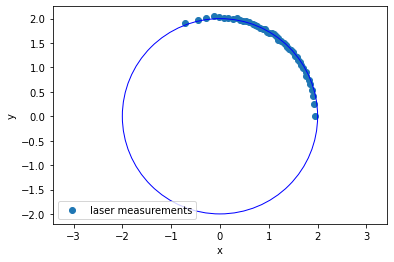

In [18]:
# If we now look at the solution, we finally see a good fit of the points to the circle
plt.axis('equal')
ax = plt.gca()
ax.scatter(xy[:, 0] + res.x[0], xy[:, 1] + res.x[1], label='laser measurements')
ax.add_patch(plt.Circle(circle_origin, circle_radius, color='b', fill=False))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

In [19]:
# Now in this particular case we might have directly gone ahead and minimzed the covariance
# along the polar coordinates 'y-axis', that is the distance values. Since we already know 
# the resulting points should form a flat line we therefore could have simply taken S[1, 1]
# as the residual. This would have likely led to a way better convergence behaviour. 
# However our goal here was to showcase the more general eigenvalue case, that why we 
# went ahead with this approach.